# 🛒 E-Commerce Sales Analysis using SQL & Python

In [39]:
# pip install mysql-connector-python

## 📥 Data Import and MySQL Database Setup

Before performing SQL analysis, the raw CSV files were imported into a MySQL database using Python.

This script automates the complete database setup process by:

- Establishing a connection to the MySQL server using `mysql.connector`.
- Reading multiple CSV files using Pandas.
- Automatically detecting the appropriate SQL data type for each column.
- Creating MySQL tables dynamically.
- Cleaning column names for SQL compatibility.
- Handling missing values (NaN → NULL).
- Loading all records into their respective MySQL tables.
- Committing the data into the database for further SQL analysis.

This automated pipeline eliminates manual table creation and enables efficient loading of large datasets into MySQL.

In [ ]:
# ----------------------------------------------------------
# Step 1 : Import E-Commerce CSV files into MySQL Database
# ----------------------------------------------------------

# This script:
# 1. Connects to the MySQL server
# 2. Reads multiple CSV files using Pandas
# 3. Automatically creates MySQL tables
# 4. Detects SQL data types dynamically
# 5. Inserts all records into the database
# 6. Handles missing values by converting NaN to SQL NULL

## ✅ Database Successfully Created

After executing the script, the following tables were created inside the **ecommerce** database:

- Customers
- Orders
- Order Items
- Payments
- Products
- Sellers
- Geolocation

These tables were then used throughout the project to perform SQL queries, business analysis, and data visualization.

## 📑 Table of Contents

1. Project Overview
2. Dataset Information
3. Technologies Used
4. Database Setup (Python → MySQL)
5. SQL Business Questions
6. Data Visualization
7. Key Insights
8. Conclusion

## 📖 Project Overview

This project analyzes an E-Commerce dataset using **SQL** and **Python** to extract meaningful business insights. The analysis focuses on customer behavior, sales performance, seller performance, payment trends, and customer retention using real-world business scenarios.

The project demonstrates the use of advanced SQL concepts such as **Joins, Window Functions, Common Table Expressions (CTEs), Aggregate Functions, Ranking Functions, and Analytical Queries**, followed by Python for data visualization.

---

## 🎯 Objectives

- Analyze sales performance across different years and months.
- Identify top-performing product categories.
- Evaluate customer purchasing behavior.
- Measure seller performance and revenue.
- Analyze payment methods and installment usage.
- Calculate cumulative sales and moving averages.
- Perform customer retention and Year-over-Year (YoY) analysis.

---

## 🛠️ Technologies Used

- Python
- MySQL
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## 📂 Dataset

The dataset contains information related to:

- Customers
- Orders
- Order Items
- Payments
- Products
- Sellers
- Product Categories

---

## 📌 Business Questions Covered

✔ Basic SQL Queries

✔ Intermediate SQL Analysis

✔ Advanced SQL Analysis using Window Functions

✔ Business Insights

✔ Data Visualization

## 📂 Dataset Information

The dataset contains transactional information from an E-Commerce platform.

### Tables Used

- Customers
- Orders
- Order Items
- Payments
- Products
- Sellers
- Geolocation

These tables were imported into MySQL using Python before performing SQL analysis.

### SQL Question 

In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

db = mysql.connector.connect(host="localhost",
                            username = 'root',
                            password='root',
                            database='ecommerce')

cur = db.cursor()


### Question 1:. List all unique cities where customers are located.

In [2]:
query = """ Select distinct customer_city from customers """
cur.execute(query)
data = cur.fetchall()
print(f"Unique Cities where customers located:\n")
df = pd.DataFrame(data)
df.head(5)

Unique Cities where customers located:



,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


### Question 2: Count the number of orders placed in 2017.

In [3]:
query = """ Select count(order_id)  from orders
            where year(order_purchase_timestamp) = 2017 """
cur.execute(query)
data = cur.fetchall()
print(f"Total Orders placed in 2017 are : {data[0][0]}")

Total Orders placed in 2017 are : 45101


### Question 3: Find the total sales per category.

In [4]:
query = """ select upper(p.product_category) as category, 
round(sum(py.payment_value),2) sales
from products p join order_items oi
on p.product_id = oi.product_id
join payments py
on py.order_id = oi.order_id
group by category
"""
cur.execute(query)
data = cur.fetchall()
print(f"Total Sales As per Category\n")

df = pd.DataFrame(data, columns = ["Category", "Sales"])
print(df)

Total Sales As per Category

                       Category       Sales
0                     PERFUMERY   506738.66
1          FURNITURE DECORATION  1430176.39
2                     TELEPHONY   486882.05
3                BED TABLE BATH  1712553.67
4                    AUTOMOTIVE   852294.33
..                          ...         ...
69               CDS MUSIC DVDS     1199.43
70                   LA CUISINE     2913.53
71  FASHION CHILDREN'S CLOTHING      785.67
72                     PC GAMER     2174.43
73       INSURANCE AND SERVICES      324.51

[74 rows x 2 columns]


### Question 4: Calculate the percentage of orders that were paid in installments.

In [5]:
query = """ select (SUM(case when payment_installments >= 1 then 1
	            else 0 end)) / count(*) * 100 from payments; """

cur.execute(query)
data = cur.fetchall()
print(f"The percentage of orders that were Paid In Installmenst:\n{data}")

The percentage of orders that were Paid In Installmenst:
[(Decimal('99.9981'),)]


## Question 5: Count the number of customers from each state. 

Count of Number of Customers from each State:

   state  customer_count
0     SP           41746
4     RJ           12852
2     MG           11635
5     RS            5466
3     PR            5045
1     SC            3637
9     BA            3380
13    DF            2140
8     ES            2033
7     GO            2020
15    PE            1652
12    CE            1336
6     PA             975
16    MT             907
10    MA             747
11    MS             715
21    PB             536
23    PI             495
14    RN             485
19    AL             413
25    SE             350
22    TO             280
20    RO             253
17    AM             148
24    AC              81
18    AP              68
26    RR              46


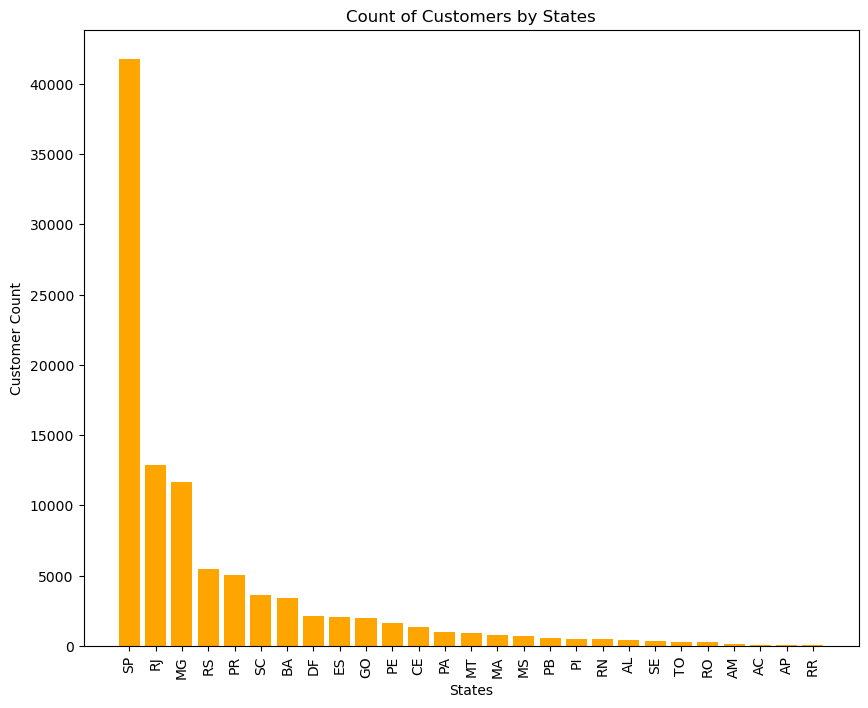

In [6]:
query = """ select customer_state, count(customer_id)
from customers
group by customer_state; """

cur.execute(query)
data = cur.fetchall()
print(f"Count of Number of Customers from each State:\n")
df = pd.DataFrame(data, columns = ["state" , "customer_count"])
df = df.sort_values(by = "customer_count", ascending=False)
print(df)
plt.figure(figsize=(10,8))
plt.bar(df["state"], df['customer_count'], color = "orange")
plt.xticks(rotation = 90)
plt.xlabel("States")
plt.ylabel("Customer Count")
plt.title("Count of Customers by States")
plt.show()

### Question 6: Calculate the number of orders per month in 2018.

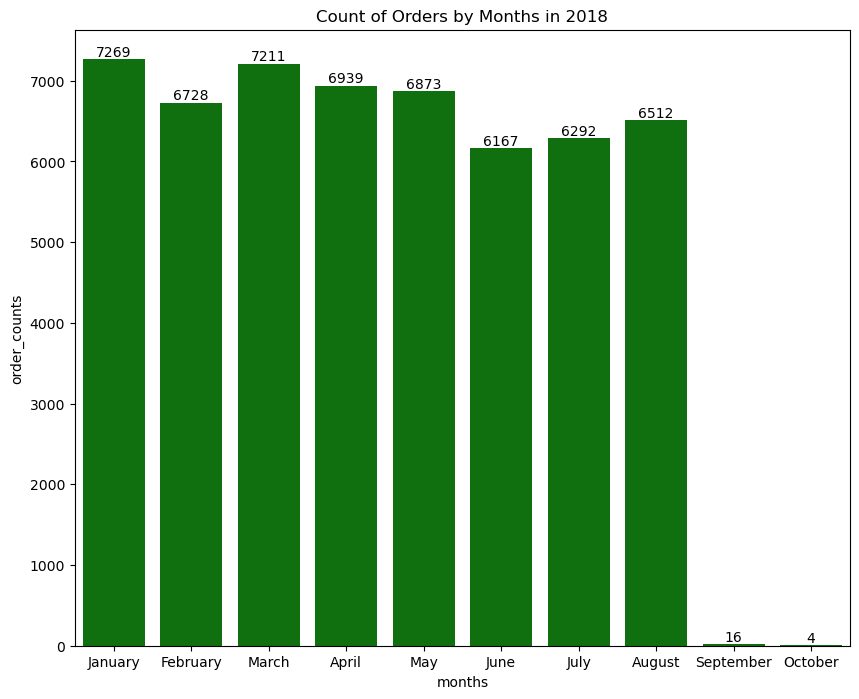

In [7]:
query = """ Select monthname(order_purchase_timestamp) months, count(order_id) order_counts
from orders
where year(order_purchase_timestamp) = 2018
group by months; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", 'order_counts'])

o = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']

plt.figure(figsize=(10,8))
ax = sns.barplot(x = df['months'], y = df["order_counts"], data = df, order = o, color = "green")
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months in 2018")
plt.show()

### Question 7: Find the average number of products per order, grouped by customer city.

In [9]:
query = """ with count_per_order as
(select o.order_id, o.customer_id, count(oi.order_id) as oc # order_count
from orders o join order_items oi
on o.order_id = oi.order_id
group by o.order_id, o.customer_id)

select c.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers c join count_per_order
on c.customer_id = count_per_order.customer_id
group by c.customer_city
order by average_orders desc; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Customer_city", 'Average_orders'])
df.head(10)

,Customer_city,Average_orders
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


### Question 8: Calculate the percentage of total revenue contributed by each product category.

In [10]:
query = """ select upper(p.product_category) as category, 
   round((sum(py.payment_value) / (Select sum(payment_value) from payments))*100, 2) sales_percentage
from products p join order_items oi
on p.product_id = oi.product_id
join payments py
on py.order_id = oi.order_id
group by category
order by sales_percentage desc; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Category", 'Percentage Distribution'])
df.head(10)

,Category,Percentage Distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
5,SPORT LEISURE,8.70
6,HOUSEWARES,6.84
7,AUTOMOTIVE,5.32
8,GARDEN TOOLS,5.24
9,COOL STUFF,4.87


### Question 9: Identify the correlation between product price and the number of times a product has been purchased.

In [19]:
query = """ Select p.product_category,
count(oi.product_id),
round(avg(oi.price),2)
from products p join order_items oi
on p.product_id = oi.product_id
group by p.product_category; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Category", 'Order_Count', "Price"])
print(df.head())
arr1 = df["Order_Count"]
arr2 = df['Price']
print()
a = np.corrcoef([arr1, arr2])
print("The Correlation Between Price and Number Of times a product has been purchased is\n", a[0][-1])

               Category  Order_Count   Price
0         HEALTH BEAUTY         9670  130.16
1         sport leisure         8641  114.34
2            Cool Stuff         3796  167.36
3  computer accessories         7827  116.51
4       Watches present         5991  201.14

The Correlation Between Price and Number Of times a product has been purchased is
 -0.10631514167157562


### Question 10: Calculate the total revenue generated by each seller, and rank them by revenue.


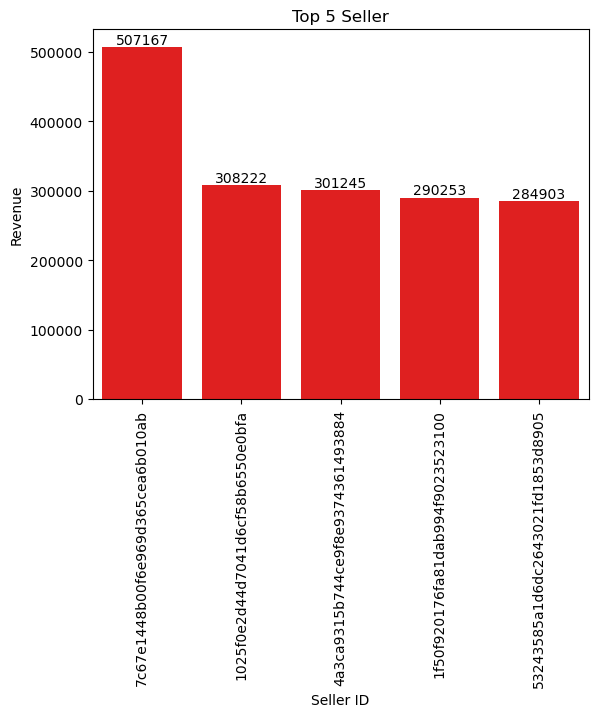

In [27]:
query = """ select *, dense_rank() Over(order by revenue desc) as rn from 
(select oi.seller_id, sum(p.payment_value) revenue
from order_items oi join payments p
on oi.order_id = p.order_id
group by oi.seller_id) as a; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Seller ID" , "Revenue", "Rank"])
df = df.head()
ax = sns.barplot(x = "Seller ID", y = "Revenue", data =df, color="red")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.title("Top 5 Seller")
plt.show()

### Question 11: Calculate the moving average of order values for each customer over their order history.

In [28]:
query = """ select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select o.customer_id, o.order_purchase_timestamp, 
p.payment_value as payment
from payments p join orders o
on p.order_id = o.order_id) as a; """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Customer ID" , "Order Purchase TimeStamp", "Payment", "Moving Average"])
df

,Customer ID,Order Purchase TimeStamp,Payment,Moving Average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


### Question 12: Calculate the cumulative sales per month for each year.

In [29]:
query = """ Select years, months, payment,
round(sum(payment) over(order by years, months),2) as cumulative_sales from 
(Select year(o.order_purchase_timestamp) as years, 
month(o.order_purchase_timestamp) as months,
round(sum(p.payment_value),2) as payment
from orders o join payments p
on o.order_id = p.order_id
group by years , months
order by years, months) as a; """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Years" , "Months", "Payment", "Cumulative Sales"])
df

,Years,Months,Payment,Cumulative Sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


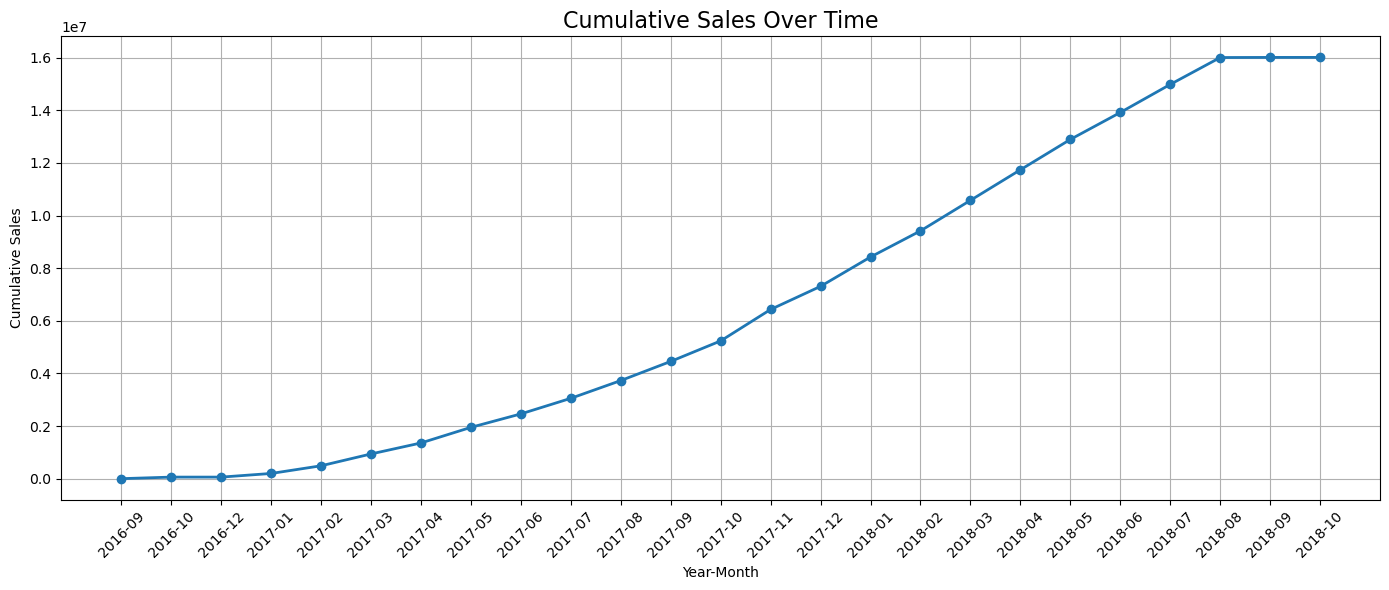

In [30]:
import matplotlib.pyplot as plt

# Create a date label
df["Date"] = df["Years"].astype(str) + "-" + df["Months"].astype(str).str.zfill(2)

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Cumulative Sales"],
         marker='o', linewidth=2)

plt.title("Cumulative Sales Over Time", fontsize=16)
plt.xlabel("Year-Month")
plt.ylabel("Cumulative Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Question 13: Calculate the year-over-year growth rate of total sales.

In [32]:
query = """ with a as
(Select year(o.order_purchase_timestamp) as years, 
round(sum(p.payment_value),2) as payment
from orders o join payments p
on o.order_id = p.order_id
group by years
order by years)

select years, ((payment - lag(payment, 1) over(order by years)) / 
lag(payment, 1) over(order by years))* 100
 previous_year from a;
 """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Years", "yoy % Growth"])
df

,Years,yoy % Growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


### Question 14: Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [33]:
query = """ with a as
(
select c.customer_id, min(o.order_purchase_timestamp) first_order
from customers c join orders o
on c.customer_id = o.customer_id
group by c.customer_id),

b as (select a.customer_id, count(Distinct o.order_purchase_timestamp) next_order
from a join orders o
on o.customer_id = a.customer_id
and o.order_purchase_timestamp > first_order
and o.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)

select 100* (count(distinct a.customer_id) / count(distinct b.customer_id))
from a left join b on a.customer_id = b.customer_id;
 """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["percentage"])
df

,percentage
0,None


#### Comment: None of Customer purchase within 6 months of their first purchase.

## Question 15: Identify the top 3 customers who spent the most money in each year.

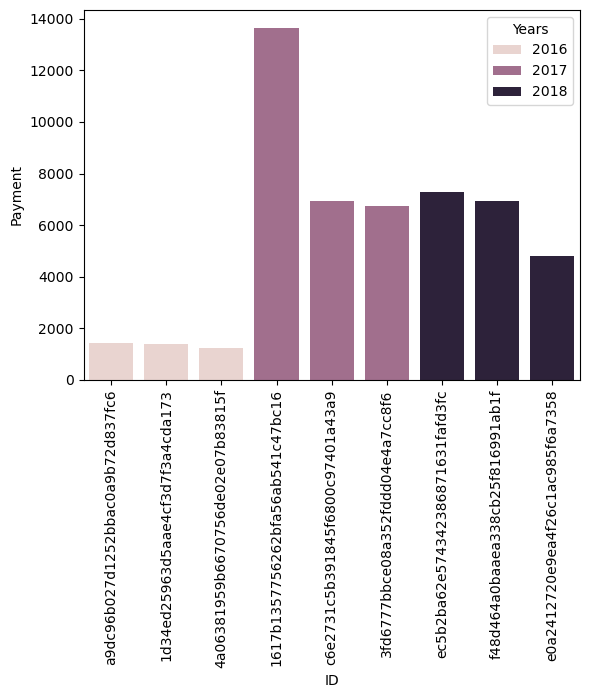

In [38]:
query = """ select years, customer_id, payment, D_rank from 
(
select year(o.order_purchase_timestamp) years,
o.customer_id, 
round(sum(p.payment_value),2) payment,
dense_rank() over(partition by year(o.order_purchase_timestamp) 
order by sum(p.payment_value) desc) D_rank
from orders o join payments p
on p.order_id = o.order_id
group by year(o.order_purchase_timestamp),	 o.customer_id) as a
where D_rank <= 3;
 """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Years", "ID", "Payment", "Rank"])

sns.barplot(x = "ID", y = "Payment", data=df, hue="Years")
plt.xticks(rotation=90)

plt.show()

# 📊 Key Business Insights

- Total sales increased steadily over the observed period.
- A small number of product categories generated the majority of revenue.
- Seller revenue was highly concentrated among top-performing sellers.
- Most customers completed purchases using installment payments.
- Window functions helped identify customer spending trends and yearly rankings.

# 📌 Conclusion

This project demonstrates an end-to-end E-Commerce data analysis workflow using SQL and Python.

The project includes:

- Data import from CSV into MySQL
- SQL data exploration
- Advanced SQL Window Functions
- Business KPI analysis
- Data visualization
- Business insights

This project highlights practical SQL and Python skills commonly required for Data Analyst roles.